# **Caso #1**

In [ ]:
# Instalar los paquetes
install.packages("mosaicData")
install.packages("car")        # Para el gráfico QQ-plot
install.packages("nortest")    # Para A-D y Lilliefors (K-S-L)
install.packages("fBasics")    # Para D’Agostino-Pearson
install.packages("moments")    # Para Curtosis y simetría

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘timeDate’, ‘timeSeries’, ‘gss’, ‘stabledist’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Cargar los paquetes
library(mosaicData)
library(car)
library(nortest)
library(fBasics)
library(moments)

Loading required package: carData


Attaching package: ‘fBasics’


The following object is masked from ‘package:car’:

    densityPlot



Attaching package: ‘moments’


The following objects are masked from ‘package:fBasics’:

    kurtosis, skewness




In [ ]:
# Cargar la base de datos
data("KidsFeet")
str(KidsFeet)

'data.frame':	39 obs. of  8 variables:
 $ name      : Factor w/ 36 levels "Abby","Alisha",..: 10 24 36 20 23 34 13 4 14 8 ...
 $ birthmonth: int  5 10 12 1 2 3 2 6 5 9 ...
 $ birthyear : int  88 87 87 88 88 88 88 88 88 88 ...
 $ length    : num  24.4 25.4 24.5 25.2 25.1 25.7 26.1 23 23.6 22.9 ...
 $ width     : num  8.4 8.8 9.7 9.8 8.9 9.7 9.6 8.8 9.3 8.8 ...
 $ sex       : Factor w/ 2 levels "B","G": 1 1 1 1 1 1 1 2 2 1 ...
 $ biggerfoot: Factor w/ 2 levels "L","R": 1 1 2 1 1 2 1 1 2 2 ...
 $ domhand   : Factor w/ 2 levels "L","R": 2 1 2 2 2 2 2 2 2 1 ...


La siguiente intrucción se usa para dividir (o separar) la variable length (longitud del pie) por sexo:

feet$length: es un vector con todas las longitudes de pies de los niños y niñas.

feet$sex: es un vector con el sexo correspondiente (B o G).

La función split(...) divide el vector de longitudes en dos grupos, uno para cada nivel del factor sex:

feetsplit$B: longitudes de pies de los niños.

feetsplit$G: longitudes de pies de las niñas.




In [ ]:
feetsplit <- split(KidsFeet$length, KidsFeet$sex)
print(feetsplit)

$B
 [1] 24.4 25.4 24.5 25.2 25.1 25.7 26.1 22.9 27.5 24.8 26.1 27.0 24.0 24.4 27.1
[16] 25.5 24.2 23.9 23.6 24.7

$G
 [1] 23.0 23.6 26.0 23.7 24.0 24.7 26.7 25.5 24.0 24.5 24.2 26.1 24.0 22.5 24.5
[16] 22.9 26.0 21.6 24.6



## Estudio gráfico de la normalidad.

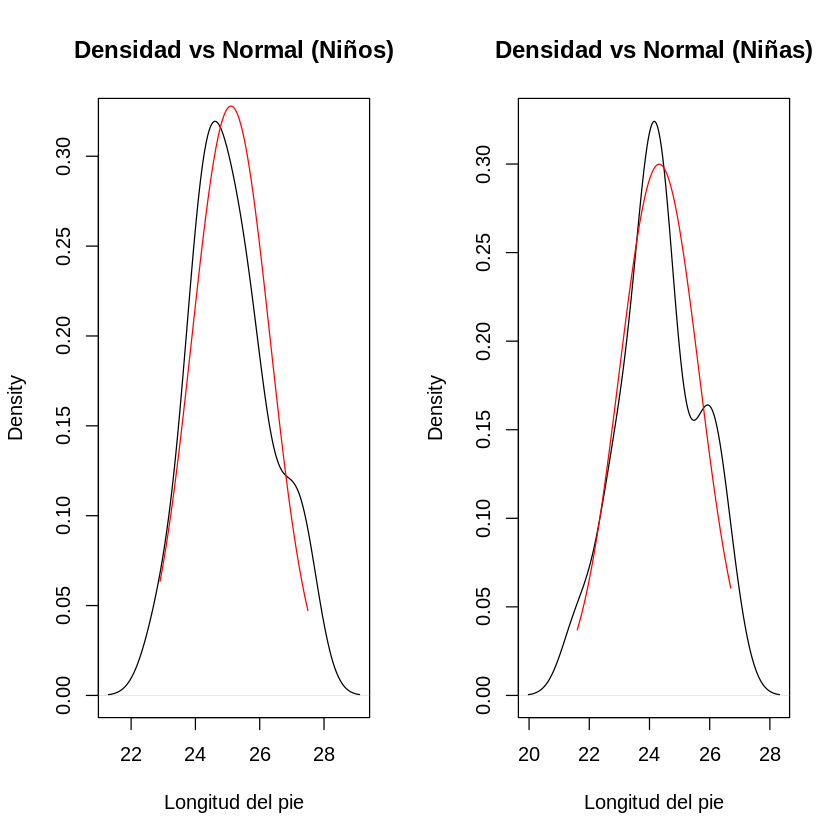

In [ ]:
# Extraer los datos
niños <- feetsplit$B
niñas <- feetsplit$G

par(mfrow = c(1, 2))

#Niños
plot(density(niños), main = "Densidad vs Normal (Niños)", xlab = "Longitud del pie")
x_n <- seq(min(niños), max(niños), by = 0.01)
u_n <- mean(niños)
sigma_n <- sd(niños)
lines(x_n, dnorm(x_n, mean = u_n, sd = sigma_n), col = "red")

# Niñas
plot(density(niñas), main = "Densidad vs Normal (Niñas)", xlab = "Longitud del pie")
x_g <- seq(min(niñas), max(niñas), by = 0.01)
u_g <- mean(niñas)
sigma_g <- sd(niñas)
lines(x_g, dnorm(x_g, mean = u_g, sd = sigma_g), col = "red")

### Analisis
Sí, se puede intuir una cierta aproximación a la normalidad en ambos grupos, aunque con diferencias sutiles:

Niños: La curva de densidad empírica (negra) es bastante parecida a la curva normal (roja), especialmente en el centro. Sin embargo, presenta una ligera asimetría a la derecha,lo que indica una posible desviación leve de la normalidad.

Niñas: También hay una forma similar a la curva normal, pero se observan pequeñas diferencias, como una mayor concentración en el centro y una cola derecha algo más pronunciada.

## Gráfico QQ-plot

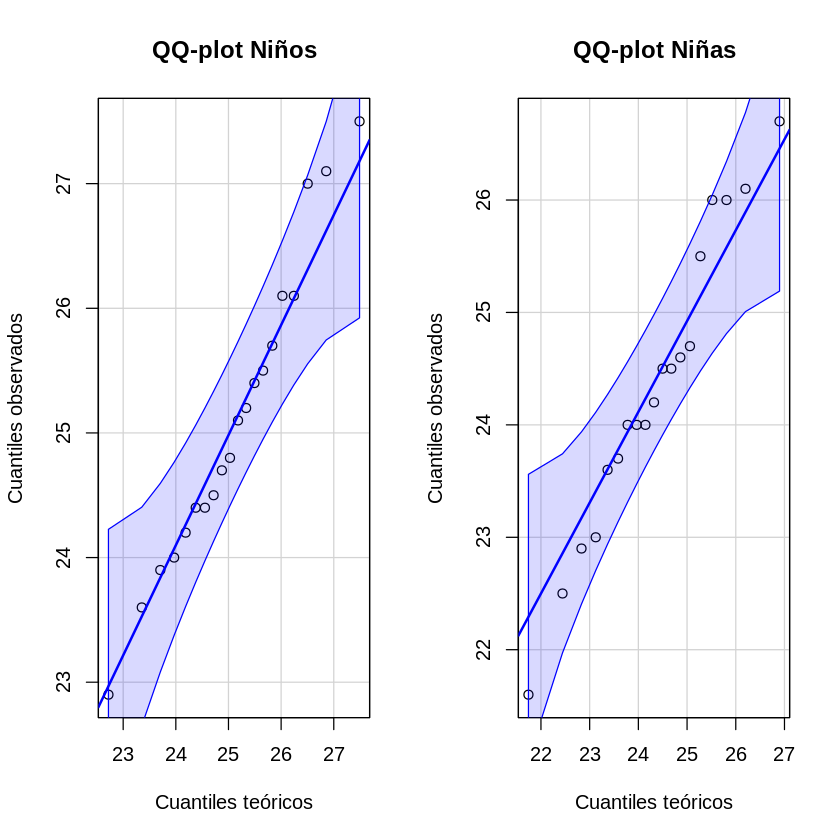

In [ ]:
par(mfrow = c(1, 2))

# QQ-plot para NIÑOS
qqPlot(niños, distribution = "norm", mean = u_n, sd = sigma_n, id=FALSE,
       main = "QQ-plot Niños", xlab = "Cuantiles teóricos", ylab = "Cuantiles observados")

# QQ-plot para NIÑAS
qqPlot(niñas, distribution = "norm", mean = u_g, sd = sigma_g, id=FALSE,
       main = "QQ-plot Niñas", xlab = "Cuantiles teóricos", ylab = "Cuantiles observados")

### Analisis
Niños:los puntos del gráfico QQ-plot para los niños se alinean bastante bien a lo largo de la línea diagonal, y la mayoría se mantiene dentro del intervalo de confianza (área azul). Esto indica que los datos pueden ser considerados aproximadamente normales.

Niñas:los puntos también siguen una trayectoria cercana a la línea diagonal, aunque con una ligera curvatura al inicio y al final. Aun así, la mayoría de los puntos cae dentro del área de confianza, por lo que también podría asumirse normalidad, aunque con una ligera desviación.

## Pruebas formales de normalidad S-W test, A-D test, K-S-L test

In [ ]:
#Para los niños
niños <- feetsplit$B
# Shapiro-Wilk
shapiro.test(niños)

# Anderson-Darling
ad.test(niños)

# Kolmogorov-Smirnov con Lilliefors
lillie.test(niños)


	Shapiro-Wilk normality test

data:  niños
W = 0.97195, p-value = 0.7954



	Anderson-Darling normality test

data:  niños
A = 0.24361, p-value = 0.7311



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  niños
D = 0.098964, p-value = 0.8746


###Analisis de los niños
En las tres pruebas, el valor p es mucho mayor a 0.05, por lo tanto, no hay evidencia suficiente para rechazar la hipótesis de normalidad en los datos de longitud del pie de los niños. Se puede asumir normalidad.

In [ ]:
#Para las niñas
niñas <- feetsplit$G
# Shapiro-Wilk
shapiro.test(niñas)

# Anderson-Darling
ad.test(niñas)

# Kolmogorov-Smirnov con Lilliefors
lillie.test(niñas)


	Shapiro-Wilk normality test

data:  niñas
W = 0.97303, p-value = 0.835



	Anderson-Darling normality test

data:  niñas
A = 0.26721, p-value = 0.6464



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  niñas
D = 0.12471, p-value = 0.6094


###Analisis de las niñas
Todos los valores p son superiores a 0.05, lo que indica que los datos de longitud del pie de las niñas también pueden considerarse normalmente distribuidos.

## ¿Es posible aplicar la prueba de D’Agostino-Pearson?
Sí, es posible aplicarla si el tamaño de muestra es mayor a 20 pero es posible aplicarlo para el grupo de niños, ya que su tamaño de muestra cumple con el requisito mínimo de 20 observaciones.
En cambio, no se puede aplicar en el grupo de niñas, porque la muestra es menor a 20, y la función dagoTest lanza un error si no se cumple este requisito.

In [ ]:
niños <- feetsplit$B

# D'Agostino-Pearson test
dagoTest(niños)


Title:
 D'Agostino Normality Test

Test Results:
  STATISTIC:
    Chi2 | Omnibus: 0.6384
    Z3  | Skewness: 0.7831
    Z4  | Kurtosis: -0.1584
  P VALUE:
    Omnibus  Test: 0.7267 
    Skewness Test: 0.4335 
    Kurtosis Test: 0.8742 


### Analisis
Dado que todos los p-valores son mayores a 0.05, no existe evidencia estadísticamente significativa para rechazar la hipótesis de normalidad.

## Curtosis y simetría del paquete moments.

In [ ]:
# Calcular curtosis y simetría
curtosis_niños <- kurtosis(niños)
simetria_niños <- skewness(niños)

curtosis_niñas <- kurtosis(niñas)
simetria_niñas <- skewness(niñas)

par(mfrow = c(1, 2))


cat("Niños - Curtosis:", round(curtosis_niños, 2), "Simetría:", round(simetria_niños, 2), "\n")
cat("Niñas - Curtosis:", round(curtosis_niñas, 2), "Simetría:", round(simetria_niñas, 2), "\n")

Niños - Curtosis: 2.46 Simetría: 0.35 
Niñas - Curtosis: 2.5 Simetría: -0.04 


### Analisis

Niños:

Simetría (skewness): 0.3527
Es un valor pequeño (cerca de 0), se puede considerar que la distribución es casi simétrica.

Curtosis: 2.4634
Este valor es ligeramente menor que 3, lo que sugiere que se puede considerar aproximadamente normal.

Niñas:

Simetría (skewness): -0.0434
Este valor es muy cercano a 0, lo que indica que la distribución es prácticamente simétrica.

Curtosis: 2.4962
También es ligeramente menor que 3, lo que indica que tiene un comportamiento bastante cercano al de una distribución normal.


# **Caso #2**

In [ ]:
# Cargar datos desde la URL
url <- 'https://raw.githubusercontent.com/fhernanb/datos/master/medidas_cuerpo'
datos <- read.table(file = url, header = TRUE)

# Extraer variable
biceps <- datos$biceps
biceps

[1] 35.8 35.0 38.5 32.2 32.9 38.5 38.3 35.0 32.1 40.4 36.5 34.2 35.2 34.0 34.8
[16] 38.6 36.4 34.0 24.3 27.8 24.0 28.0 26.9 26.5 24.1 29.2 29.0 33.6 24.8 25.4
[31] 25.9 24.0 25.6 26.0 23.5 31.0

## Estudio gráfico de la normalidad.

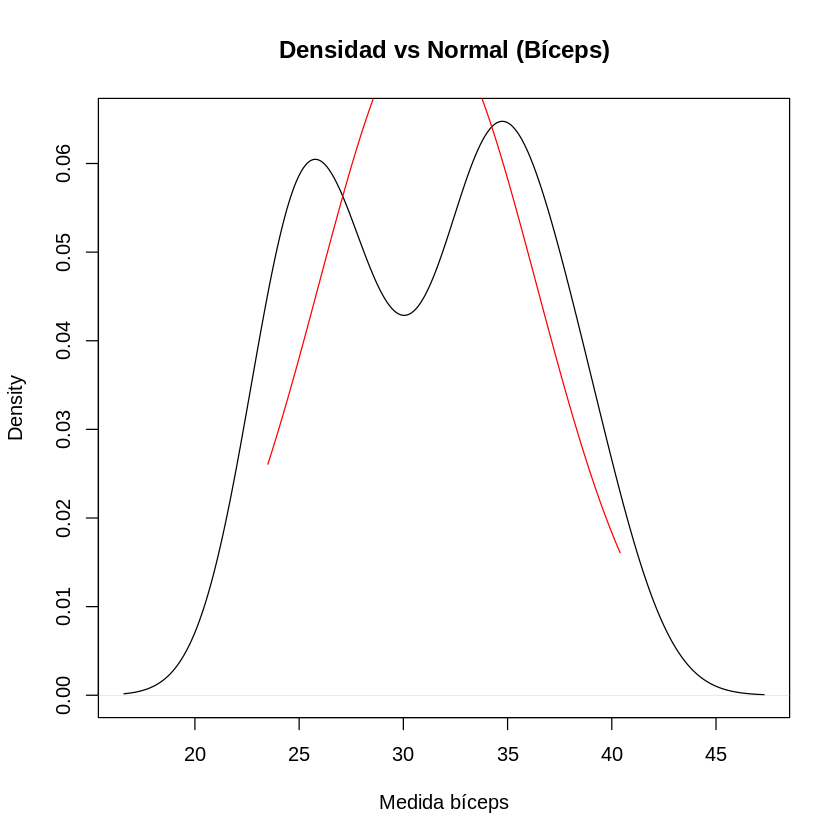

In [ ]:
# Crear gráfico de densidad y compararlo con la curva normal teórica
plot(density(biceps), main = "Densidad vs Normal (Bíceps)", xlab = "Medida bíceps")
x_vals <- seq(min(biceps), max(biceps), by = 0.01)
media <- mean(biceps)
desv <- sd(biceps)
lines(x_vals, dnorm(x_vals, mean = media, sd = desv), col = "red")


### Analisis
El gráfico no sugiere normalidad para los datos de la variable bíceps.
La presencia de dos modos indica que los datos no siguen una distribución normal

## Gráfico QQ-plot

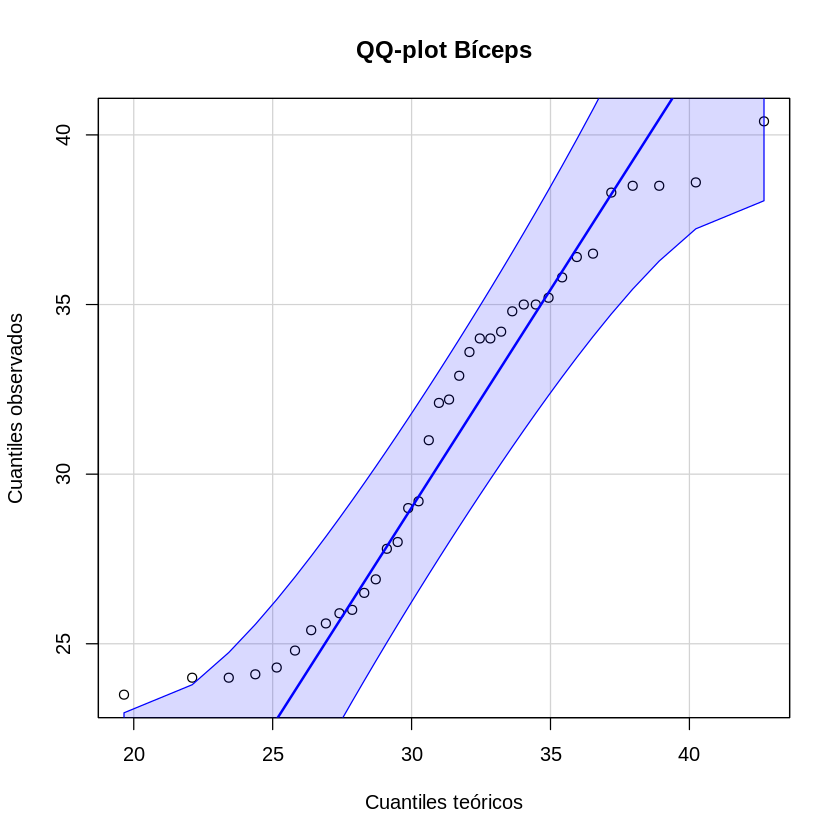

In [ ]:
qqPlot(biceps, distribution = "norm", mean = media, sd = desv,
       id = FALSE, main = "QQ-plot Bíceps", xlab = "Cuantiles teóricos", ylab = "Cuantiles observados")

### Analisis
El QQ-plot sugiere que los datos de la variable bíceps no siguen una distribución normal.

Aunque la mayoría de los puntos están dentro del área de confianza, la forma no es lineal, lo que refuerza la evidencia visual de no normalidad.


## Pruebas formales de normalidad S-W test, A-D test, K-S-L test

In [ ]:
# Shapiro-Wilk
shapiro.test(biceps)

# Anderson-Darling
ad.test(biceps)

# Kolmogorov-Smirnov-Lilliefors
lillie.test(biceps)


	Shapiro-Wilk normality test

data:  biceps
W = 0.92377, p-value = 0.01627



	Anderson-Darling normality test

data:  biceps
A = 0.94278, p-value = 0.0151



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  biceps
D = 0.12583, p-value = 0.1588


### Analisis
Shapiro-Wilk test:

p-valor = 0.01627 -> Rechaza la normalidad (p < 0.05)

Anderson-Darling test:

p-valor = 0.0151 -> Rechaza la normalidad (p < 0.05)

Lilliefors (Kolmogorov-Smirnov) test:

p-valor = 0.1588 -> No rechaza la normalidad (p > 0.05)

Dos de las tres pruebas presentan p-valores menores a 0.05, lo que indica evidencia estadística suficiente para rechazar la hipótesis de normalidad.

## D’Agostino-Pearson

In [ ]:
dagoTest(biceps)


Title:
 D'Agostino Normality Test

Test Results:
  STATISTIC:
    Chi2 | Omnibus: 13.6459
    Z3  | Skewness: 0.0162
    Z4  | Kurtosis: -3.694
  P VALUE:
    Omnibus  Test: 0.001088 
    Skewness Test: 0.9871 
    Kurtosis Test: 0.0002208 


### Analisis
El test de D’Agostino-Pearson indica que los datos de bíceps no siguen una distribución normal, debido a un valor de curtosis anormalmente bajo


## Curtosis y simetría

In [ ]:
curtosis <- kurtosis(biceps)
simetria <- skewness(biceps)

# Mostrar valores numéricos
cat("Curtosis:", round(curtosis, 2), "\n")
cat("Simetría:", round(simetria, 2), "\n")

Curtosis: 1.63 
Simetría: 0.01 


### Analisis
Curtosis: 1.63 -> Está muy por debajo de 3
Simetría: 0.01 -> Muy cercana a 0, lo que indica que la distribución es prácticamente simétrica.

Aunque la distribución de los datos es simétrica, la curtosis notablemente baja indica que la forma general de la distribución se aleja de la normal

## Tabla Caso 1 y 2

### Prueba de normalidad: Longitud del pie y Medidas de bíceps

| Tipo de prueba                    | Longitud del pie - Niños                            | Longitud del pie - Niñas                            | Medidas de bíceps                              |
|----------------------------------|-----------------------------------------------------|-----------------------------------------------------|------------------------------------------------|
| **Función de densidad vs normal**| Curva similar a normal, ligera asimetría derecha    | Curva similar a normal, leves diferencias en colas  | Doble pico, no sugiere normalidad              |
| **Conclusión**                   | Compatible con normalidad                           | Compatible con normalidad                           | No compatible con normalidad                   |
| **QQ-Plot**                      | Puntos alineados                                    | Puntos alineados, leve curvatura                    | Curvatura clara, desvío de la recta            |
| **Conclusión**                   | Compatible con normalidad                           | Compatible con normalidad                           | No compatible con normalidad                   |
| **S-W test**                     | p = 0.7954                                          | p = 0.835                                           | p = 0.016                                      |
| **Conclusión**                   | No se rechaza normalidad                            | No se rechaza normalidad                            | Se rechaza normalidad                          |
| **A-D test**                     | p = 0.7311                                          | p = 0.6464                                          | p = 0.0151                                     |
| **Conclusión**                   | No se rechaza normalidad                            | No se rechaza normalidad                            | Se rechaza normalidad                          |
| **K-S-L test**                   | p = 0.8746                                          | p = 0.6094                                          | p = 0.1588                                     |
| **Conclusión**                   | No se rechaza normalidad                            | No se rechaza normalidad                            | No se rechaza normalidad                       |
| **D’Agostino-Pearson**          | Omnibus = 0.7267, Skew = 0.4335, Kurt = 0.8742       | No aplica (< 20 datos)                              | Omnibus = 0.001088, Skew = 0.9871, Kurt = 0.0002208 |
| **Conclusión**                   | No se rechaza normalidad                            | No aplica                                           | Se rechaza normalidad                          |
| **Curtosis y simetría**         | C = 2.46, S = 0.35                                   | C = 2.5, S = -0.04                                   | C = 1.63, S = 0.01                              |
| **Conclusión**                   | Ligera asimetría, forma cercana a normal            | Muy simétrica, forma cercana a normal               | Muy simétrica, no normal                       |
| **Conclusión general**          | Sigue una distribución normal           | Sigue una distribución normal          | No siguen distribución normal                  |


# **Caso #3**

Se desea determinar si existe una relación entre el tipo de delito (homicidio, robo o asalto) y la condición del criminal (extraño o conocido/pariente), con base en datos proporcionados por el Departamento de Justicia de EE.UU. Para esto, se aplicará una prueba de independencia entre las dos variables categóricas mencionadas.

El objetivo es determinar, con un nivel de significancia del 5%, si el tipo de delito es independiente de la condición del delincuente o si existe alguna relación entre estas dos variables categóricas.

Dado que ambas variables (tipo de delito y condición del criminal son cualitativas y se representan en forma de tabla de contingencia, la prueba más adecuada es una prueba de independencia Chi-cuadrado.

Con esto se establecen dos hipotesis

Hipótesis nula
𝐻0
: El tipo de delito es independiente de la condición del criminal.

Hipótesis alternativa
𝐻1
: El tipo de delito depende de la condición del criminal.

In [ ]:
# Cargar librería
library(tidyverse)

# Crear tabla de contingencia
crimen_data <- matrix(
  c(12, 379, 727,
    39, 106, 642),
  nrow = 2,
  byrow = TRUE,
  dimnames = list(
    "Condición del Criminal" = c("Extraño", "Conocido/Pariente"),
    "Tipo de Delito" = c("Homicidio", "Robo", "Asalto")
  )
)

# Ejecutar prueba de independencia Chi-cuadrado
prueba_chi <- chisq.test(crimen_data)

# Extraer valores
valor_observado <- prueba_chi$statistic
gl <- prueba_chi$parameter
valor_p <- prueba_chi$p.value

# Mostrar resultados
cat("Resultado de la prueba Chi-cuadrado:\n")
cat("Estadístico observado:", round(valor_observado, 2), "\n")
cat("Grados de libertad:", gl, "\n")
cat("Valor p:", valor_p, "\n\n")

Resultado de la prueba Chi-cuadrado:
Estadístico observado: 119.33 
Grados de libertad: 2 
Valor p: 1.224111e-26 





**Se adjunta tambien la tabla del resumen de la prueba**

| **Resumen de la prueba**             | **Respuesta**                                                                                                                                                      |
| ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Tipo de prueba a utilizar            | Prueba de independencia (Chi-cuadrado)                                                                                                                             |
| Valor observado                      | 119.33                                                                                                                                                             |
| Grados de libertad y qué representan | 2                 |
| Valor P                              | 1.224111e-26                                                                                                                                                       |
| H_0                               | El tipo de delito es independiente de la condición del criminal                                                                                                    |
| H_1                                | El tipo de delito depende de la condición del criminal                                                                                                             |
| Conclusión                      | Se rechaza H_0 Existe evidencia estadísticamente significativa de que el tipo de delito depende de si el criminal es un extraño o un conocido/pariente. |


Con esto se concluye que existe evidencia suficiente significatiiva de que el tipo de delito dependende de si el criminal es un extraño o un conocido/pariente

# **Caso #4**

La seguridad de los automóviles se determina mediante diversas pruebas. Una de ellas consiste en hacer chocar un automóvil contra una barrera fija a 35
mi/h con un maniquí colocado en el asiento del conductor.

A una de las medidas utilizadas para cuantificar el impacto del choque sobre el conductor se le conoce como Desaceleración de pecho y se mide en unidades de fuerza de gravedad (
g
). Los valores más grandes indican mayores cantidades de desaceleración, las cuáles pueden provocar lesiones graves en los conductores. La siguiente tabla muestra mediciones de desaceleraciones de pecho obtenidas a partir de pruebas de choques de diferentes tipos de vehículos:

El objetivo es determinar si el tamaño del automóvil influye en la desaceleración de pecho. Es decir, queremos saber si los tres tipos de vehículos tienen diferencias significativas en sus medias de desaceleración.

Las variables son:

Variable independiente: tipo de vehículo (compacto, mediano, grande)

Variable dependiente: desaceleración de pecho (numérica)

Aplicaremos ante ello una prueba de tipo ANOVA de un solo factor esto justificado ya que:

1- Compararemos más de dos medias

2 -Se asume normalidad y varianzas similares

3 -Los grupos son independientes

Hipótesis

𝐻0
 : Las medias de desaceleración de pecho son iguales en los tres tipos de autos.

𝐻1
 : Al menos una media es diferente.

In [ ]:
# Librería necesaria
library(tidyverse)

# Creamos los vectores
compactos <- c(44, 43, 44, 54, 38, 41, 40, 45, 50)
medianos  <- c(41, 49, 43, 41, 47, 44, 41, 39, 44)
grandes   <- c(32, 37, 38, 30, 35, 37, 31, 42, 43)

# Unimos todo en un data frame
desacel_data <- data.frame(
  desaceleracion = c(compactos, medianos, grandes),
  tipo_auto = factor(rep(c("Compacto", "Mediano", "Grande"), each = 9))
)

# Ejecutamos ANOVA
modelo_anova <- aov(desaceleracion ~ tipo_auto, data = desacel_data)

# Mostramos resultados del ANOVA
resumen <- summary(modelo_anova)
print(resumen)

# Acceder a componentes del ANOVA
sst <- sum(anova(modelo_anova)[["Sum Sq"]])
ssa <- anova(modelo_anova)[["Sum Sq"]][1]
sse <- anova(modelo_anova)[["Sum Sq"]][2]
gl_total <- sum(anova(modelo_anova)[["Df"]])
gl_entre <- anova(modelo_anova)[["Df"]][1]
gl_dentro <- anova(modelo_anova)[["Df"]][2]
valor_f <- anova(modelo_anova)[["F value"]][1]
valor_p <- anova(modelo_anova)[["Pr(>F)"]][1]

# Imprimir
cat("SST:", sst, "\n")
cat("SSA (entre grupos):", ssa, "\n")
cat("SSE (dentro de grupos):", sse, "\n")
cat("GL total:", gl_total, "\n")
cat("Valor F observado:", valor_f, "\n")
cat("Valor p:", valor_p, "\n")

            Df Sum Sq Mean Sq F value   Pr(>F)    
tipo_auto    2  358.2  179.11   9.586 0.000871 ***
Residuals   24  448.4   18.69                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
SST: 806.6667 
SSA (entre grupos): 358.2222 
SSE (dentro de grupos): 448.4444 
GL total: 26 
Valor F observado: 9.585728 
Valor p: 0.0008713135 


| **Resumen de la prueba**             | **Respuesta**                                                        |
| ------------------------------------ | -------------------------------------------------------------------- |
| Tipo de prueba a utilizar            | ANOVA de un factor          |
| Valor observado (F)                  | 9.586                                                                |
| Grados de libertad y qué representan | Total: 26; Entre grupos (SSA): 2; Dentro de grupos (SSE): 24         |
| SSE                                  | 448.4444                                                             |
| SSA                                  | 358.2222                                                             |
| SST                                  | 806.6667                                                             |
| *(Mean Sq)*      | SSA/DF = 179.1111 ; SSE/DF = 18.6852                                 |
| Valor P                              | 0.000871                                                             |
| $H_0$                                | Las medias de desaceleración de los tres tipos de autos son iguales. |
| $H_1$                                | Al menos una media de desaceleración es diferente.                   |


Con esto podemos llegar a la conclusion de que el valor p = 0.000871 es menor al nivel de significancia del 5% (0.05), se rechaza la hipótesis nula
𝐻0
​
 . Esto indica que sí existen diferencias estadísticamente significativas entre las medias de desaceleración de pecho según el tipo de automóvil.

En otras palabras, el tamaño del automóvil influye en la seguridad medida mediante la desaceleración de pecho.

**4.2** - En caso de detectar alguna diferencia en cuanto a la seguridad que puede brindar al tamaño del vehículo, ¿es posible identificar en cuáles existe una verdadera diferencia significativa? De ser así, realice la prueba que corresponda e interprete el resultado.

Como esta prueba ANOVA demostro signiificacia en la diferencia de la seguridad segun el tipo de vehiculo, la prueba adecuada para identificar qué pares de grupos difieren entre sí es la prueba de comparaciones múltiples de Tukey. Esto debido a que esta prueba controla el error al hacer comparaciones múltiples y nos dice, par por par, si hay diferencia estadísticamente significativa en las medias.



In [ ]:
# Ejecutamos la prueba post hoc de Tukey
tukey <- TukeyHSD(modelo_anova)

# Mostramos resultados
print(tukey)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = desaceleracion ~ tipo_auto, data = desacel_data)

$tipo_auto
                      diff        lwr       upr     p adj
Grande-Compacto  -8.222222 -13.310970 -3.133474 0.0013517
Mediano-Compacto -1.111111  -6.199859  3.977637 0.8498413
Mediano-Grande    7.111111   2.022363 12.199859 0.0051749



| Comparación        | Diferencia de medias | Límite inferior (lwr) | Límite superior (upr) | Valor p ajustado (p adj) |
| ------------------ | -------------------- | --------------------- | --------------------- | ------------------------ |
| Grande – Compacto  | -8.222               | -13.311               | -3.133                | 0.00135                  |
| Mediano – Compacto | -1.111               | -6.200                | 3.978                 | 0.84984                  |
| Mediano – Grande   | 7.111                | 2.022                 | 12.200                | 0.00517                  |


Los resultados de la prueba post hoc de Tukey revelan que existen diferencias estadísticamente significativas en la desaceleración de pecho entre algunos pares de vehículos. En particular, se encontró que los autos grandes presentan significativamente menor desaceleración que los autos compactos, lo que indica que los autos grandes ofrecen mayor seguridad en caso de impacto. Asimismo, los autos grandes también presentan desaceleración significativamente menor que los autos medianos.

Por otro lado, no se observó una diferencia significativa entre autos compactos y medianos, lo que sugiere que estos dos grupos tienen un nivel de seguridad similar según la medida de desaceleración de pecho.

En este estudio se analizó si el tamaño del vehículo influye en la seguridad del conductor, medida mediante la desaceleración de pecho en pruebas de choque. Aplicando un análisis de varianza (ANOVA), se comprobó que existen diferencias significativas entre los tipos de vehículos. Posteriormente, mediante una prueba de comparaciones múltiples de Tukey, se identificó que los autos grandes presentan una menor desaceleración, y por tanto, mayor seguridad, en comparación con los autos compactos y medianos. No se encontraron diferencias significativas entre los autos compactos y los medianos. Estos hallazgos permiten concluir que el tamaño del vehículo sí influye en la seguridad que puede brindar en caso de colisión, siendo los autos grandes los que ofrecen mejores resultados en términos de protección del conductor.

# **CASO 5**

In [ ]:
# Libraries
# Instalar paquetes si no están ya disponibles
paquetes <- c("nortest", "ggplot2", "corrplot", "corrr", "ggcorrplot")

for (p in paquetes) {
  if (!require(p, character.only = TRUE)) {
    install.packages(p, repos = "http://cran.us.r-project.org")
    library(p, character.only = TRUE)
  } else {
    library(p, character.only = TRUE)
  }
}



# Carga de datos
url <- 'http://verso.mat.uam.es/~joser.berrendero/datos/EdadPesoGrasas.txt'
grasas <- read.table(url, header = TRUE)
head(grasas)

Loading required package: nortest

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘nortest’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2

Loading required package: corrplot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘corrplot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded

Loading required package: corrr

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘corrr’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘permute’, ‘ca’, ‘colorspace’, ‘foreach’, ‘gclus’, ‘qap’, ‘registry’, ‘TSP’, ‘vegan’, ‘ggrepel’, ‘seriation’


Loading 

,peso,edad,grasas
,<int>,<int>,<int>
1,84,46,354
2,73,20,190
3,65,52,405
4,70,30,263
5,76,57,451
6,69,25,302


## Paso 1: Análisis de correlación entre todas las variables
### Objetivo:
Analizar la fuerza y dirección de la relación entre las variables Edad, Peso y Grasas mediante un análisis de correlación.

       peso edad grasas
peso   1.00 0.24   0.27
edad   0.24 1.00   0.84
grasas 0.27 0.84   1.00


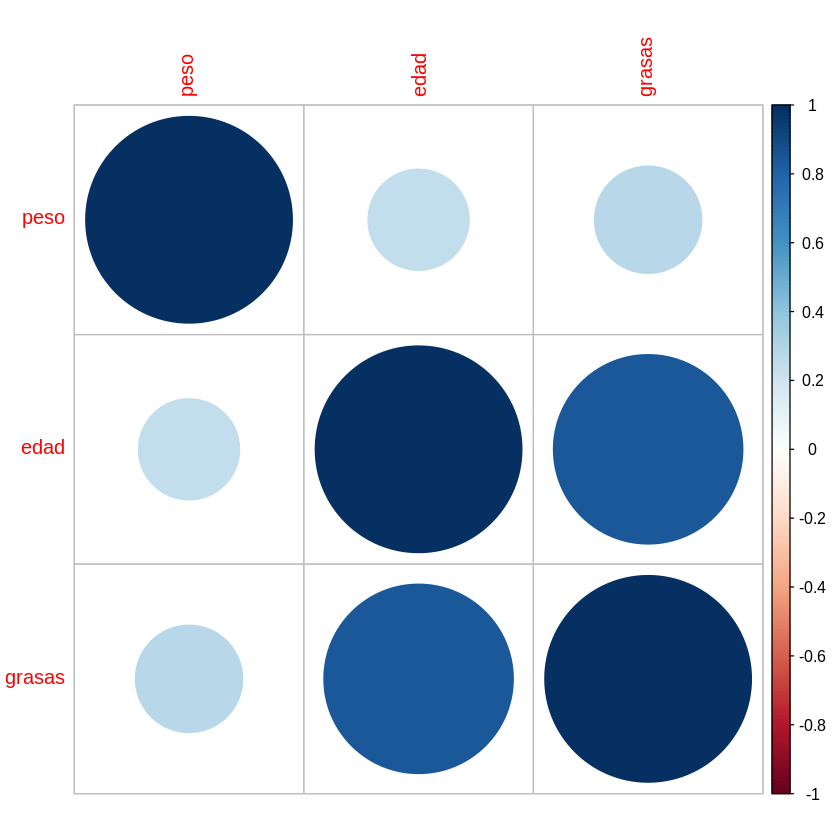

In [ ]:
cor_matrix <- round(cor(grasas), 2)
print(cor_matrix)
corrplot(cor_matrix, method = "circle")

### Interpretación:
El coeficiente de correlación más alto es entre edad y grasas (r = 0.84), lo cual indica una fuerte relación positiva. Las otras relaciones son más débiles:

peso y grasas: 0.27 (relación débil)

peso y edad: 0.24 (relación débil)

Por tanto, la mejor opción para construir un modelo de regresión es usar edad como variable explicativa para predecir grasas.

El gráfico generado por corrplot visualiza esta información de forma intuitiva: los círculos grandes y oscuros representan relaciones más fuertes en donde vemos con claridad que el coeficiente de correlación más alto es entre edad.

## Paso 2: Modelo de Regresión Lineal Simple (RLS)
### Objetivo:
Construir un modelo de regresión lineal simple entre las dos variables con mayor correlación: edad (variable explicativa) y grasas (variable respuesta). Esto nos permitirá estimar el nivel de grasa corporal en función de la edad de una persona.

In [ ]:
# Crear modelo de regresión lineal simple usando Edad para predecir Grasas
modelo <- lm(grasas ~ edad, data = grasas)
summary(modelo)


Call:
lm(formula = grasas ~ edad, data = grasas)

Residuals:
    Min      1Q  Median      3Q     Max 
-63.478 -26.816  -3.854  28.315  90.881 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 102.5751    29.6376   3.461  0.00212 ** 
edad          5.3207     0.7243   7.346 1.79e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 43.46 on 23 degrees of freedom
Multiple R-squared:  0.7012,	Adjusted R-squared:  0.6882 
F-statistic: 53.96 on 1 and 23 DF,  p-value: 1.794e-07


### Interpretación:
Las dos variables con mayor coeficiente de correlación son edad y grasas, con un valor de r = 0.84, lo que indica una relación positiva fuerte.

Se construyó un modelo de regresión lineal simple donde:
* La variable explicativa (X) es edad
* La variable respuesta (Y) es grasas

El modelo obtenido es:
* Grasas = 102.5751 + 5.3207 ⋅ Edad

Esto significa que, en promedio, el nivel de grasa corporal aumenta 5.32 unidades por cada año de edad. El modelo es estadísticamente significativo (p < 0.001) y explica aproximadamente el 70% de la variabilidad de los datos (R² = 0.7012), lo que indica un buen ajuste.

## Paso 3: Análisis de la calidad del modelo
### Objetivo:
Evaluar la calidad del modelo de regresión lineal simple entre edad (X) y grasas (Y) utilizando el coeficiente de determinación (R²) y el coeficiente de correlación (R), calculados directamente.

In [ ]:
# Calcular coeficiente de determinación y correlación
r2 <- summary(modelo)$r.squared
r <- sqrt(r2)
r2  # Coeficiente de determinación
r   # Coeficiente de correlación


[1] 0.7011607

[1] 0.8373534

### Interpretación:
R² = 0.7012: El modelo explica aproximadamente el 70.12% de la variabilidad en el nivel de grasa corporal a partir de la edad. Esto indica un buen ajuste, ya que un valor superior a 0.7 suele considerarse alto en regresión lineal simple.

R ≈ 0.8373: Existe una correlación positiva fuerte entre edad y grasa corporal. Este valor confirma que la relación lineal observada es real y consistente con el modelo ajustado.

### Conclusión:
Tanto R como R² indican que el modelo es estadísticamente sólido y explicativo, por lo que se puede afirmar que la edad es una buena variable para predecir el nivel de grasa corporal. Este análisis cumple con lo requerido metodológicamente, al mostrar explícitamente los dos coeficientes por separado y en contexto.

## Paso 4: Gráfico de dispersión con recta de mejor ajuste
### Objetivo:
Visualizar la relación entre las variables edad (variable explicativa) y grasas (variable respuesta), utilizando un gráfico de dispersión con su recta de mejor ajuste.

`geom_smooth()` using formula = 'y ~ x'


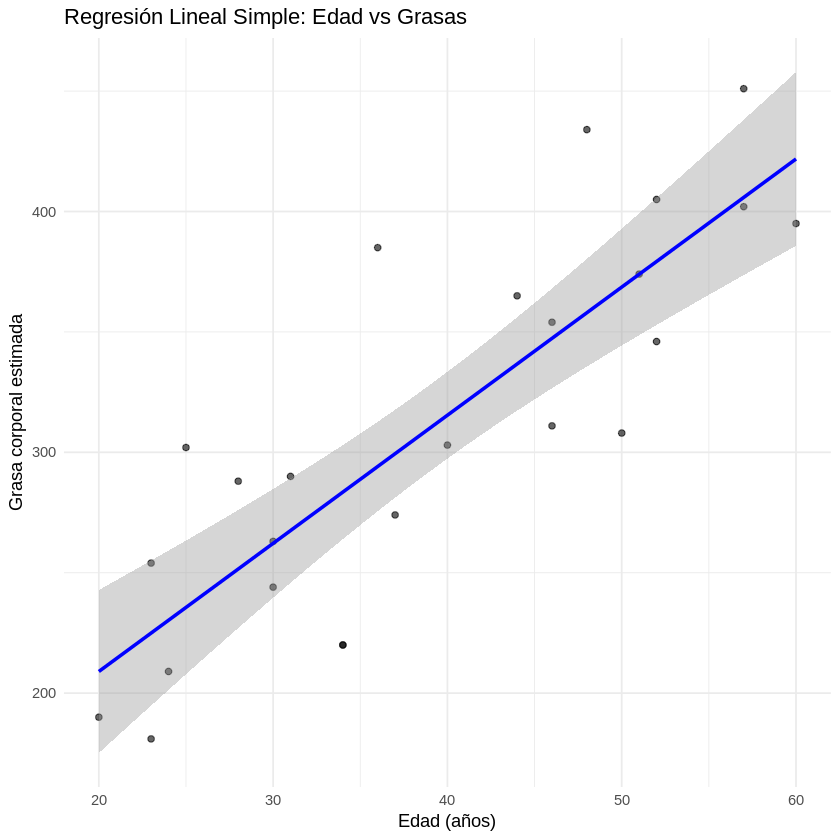

In [ ]:
# Gráfico de dispersión con recta de regresión lineal
ggplot(grasas, aes(x = edad, y = grasas)) +
  geom_point(alpha = 0.6) +  # puntos de datos
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(title = "Regresión Lineal Simple: Edad vs Grasas",
       x = "Edad (años)",
       y = "Grasa corporal estimada") +
  theme_minimal()

### Interpretación
El gráfico muestra una relación lineal creciente entre la edad y el nivel de grasa corporal. La recta azul representa la recta de mejor ajuste obtenida por mínimos cuadrados, mientras que la franja gris indica el intervalo de confianza del 95% para la media de las predicciones.

Se observa que la mayoría de los puntos están cerca de la recta, lo que respalda el buen ajuste del modelo (R² ≈ 0.70). Además, la dirección positiva confirma que a mayor edad, mayor nivel de grasa corporal estimado.

Visualmente, no se detectan patrones que indiquen un mal ajuste, lo cual valida el uso de un modelo lineal simple en este caso.

## Paso 5: Prueba de normalidad para los residuos
### Objetivo:
Verificar si los residuos del modelo de regresión lineal simple entre edad y grasa corporal siguen una distribución normal.

In [ ]:
# Calcular residuos del modelo
residuos <- modelo$residuals

# Prueba de normalidad Lilliefors (Kolmogorov-Smirnov adaptada)
lillie.test(residuos)


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuos
D = 0.10555, p-value = 0.6708


### Interpretación
Se aplicó la prueba de Lilliefors para verificar si los residuos del modelo siguen una distribución normal, condición necesaria para la validez de la regresión lineal simple.

Como el valor-p es mayor que 0.05, no se rechaza la hipótesis nula, lo que indica que los residuos se distribuyen normalmente.

Se cumple la condición de normalidad, por lo tanto, el modelo es válido para continuar con análisis inferenciales como intervalos de confianza y predicción.

## Paso 6: Intervalo de confianza del 95% para los coeficientes del modelo
### Objetivo:
Calcular los intervalos de confianza al 95%

In [ ]:
# Intervalo de confianza para los coeficientes del modelo
confint(modelo, level = 0.95)

,2.5 %,97.5 %
(Intercept),41.265155,163.885130
edad,3.822367,6.818986


### Interpretación:
El intervalo de confianza al 95% para el intercepto es [41.27, 163.89] y para la pendiente es [3.82, 6.82].

Esto indica que, con un 95% de certeza:

* La pendiente sugiere que por cada año de edad, la grasa corporal aumenta entre 3.82 y 6.82 unidades, lo que confirma una relación positiva y significativa.



## Paso 7: Intervalo de confianza y de predicción para edad = 27
### Objetivo:
Estimar dos tipos de intervalos para un valor puntual de edad (27 años):

* El intervalo de confianza (IC) para la media de grasa corporal en personas de 27 años, denotado como 𝜇𝑌∣𝑥 = 27.

* El intervalo de predicción (IP) para los valores individuales de grasa corporal de personas con esa edad.

In [ ]:
# Crear nuevo dato para edad = 27
nueva_edad <- data.frame(edad = 27)

# Intervalo de confianza para la media de grasa (mu_Y|x=27)
predict(modelo, nueva_edad, interval = "confidence", level = 0.95)

# Intervalo de predicción para un nuevo valor individual de grasa
predict(modelo, nueva_edad, interval = "prediction", level = 0.95)


,fit,lwr,upr
1,246.2334,220.6777,271.7891


,fit,lwr,upr
1,246.2334,152.7653,339.7015


Interpretación resumida:

El intervalo de confianza al 95% para 𝜇𝑌∣𝑥 = 27 es aproximadamente:

[220.68, 271.79]

Esto significa que, con un 95% de confianza, la media de grasa corporal para personas de 27 años se encuentra dentro de ese rango.

El intervalo de predicción al 95% para 𝜇𝑌∣𝑥 = 27

[152.77, 339.70]

Esto indica que una persona de 27 años tomada al azar tendrá un nivel de grasa corporal dentro de ese rango con un 95% de certeza.

El modelo permite estimar con precisión tanto el valor medio como un posible valor individual de grasa corporal para edad = 27, cumpliendo los criterios para regresión válida.

## Paso 8: Prueba de significancia para la linealidad
### Objetivo:
Evaluar si la relación entre las variables edad (explicativa) y grasa corporal (respuesta) es estadísticamente significativa, es decir, si existe dependencia lineal entre ellas. Para esto, se realiza una prueba de hipótesis sobre la pendiente del modelo de regresión.

Hipótesis planteadas:
* H₀: β₁ = 0 → No hay relación lineal entre edad y grasa corporal.

* H₁: β₁ ≠ 0 → Sí hay relación lineal significativa.

In [ ]:
summary(modelo)


Call:
lm(formula = grasas ~ edad, data = grasas)

Residuals:
    Min      1Q  Median      3Q     Max 
-63.478 -26.816  -3.854  28.315  90.881 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 102.5751    29.6376   3.461  0.00212 ** 
edad          5.3207     0.7243   7.346 1.79e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 43.46 on 23 degrees of freedom
Multiple R-squared:  0.7012,	Adjusted R-squared:  0.6882 
F-statistic: 53.96 on 1 and 23 DF,  p-value: 1.794e-07


## Interpretación:
* El valor p = 1.79e-07 para la pendiente (edad) es mucho menor que 0.05, por lo tanto, se rechaza la hipótesis nula H₀.

* Esto indica que la pendiente es estadísticamente diferente de cero, lo que confirma que sí existe una dependencia lineal significativa entre la edad de la persona y su nivel de grasa corporal.

* En otras palabras, la variable edad es un buen predictor del nivel de grasa corporal en este modelo.

Se confirma que la relación lineal es significativa y que la regresión lineal simple es válida para modelar la relación entre edad y grasa corporal. Esto respalda el uso del modelo para inferencia y predicción.



# **CASO 6**

Supóngase que el departamento de ventas de una empresa quiere estudiar la influencia
que tiene la publicidad a través de distintos medios de comunicación, sobre el número
de ventas de un producto. Se dispone de un conjunto de datos que contiene los ingresos
(en millones) conseguido por ventas en 200 regiones, así como la cantidad de
presupuesto, también en millones, destinado a anuncios por radio, TV y periódicos en
cada una de ellas.
Los datos se encuentran en el archivo DatosVentas.csv.


Para estos datos, realice los siguiente:
• Instale y cargue las librerías bbmle y DALEX

In [ ]:
install.packages("bbmle")
install.packages("DALEX")
install.packages("graphics")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘graphics’ is a base package, and should not be updated”


In [ ]:
library(stats)
library(bbmle)
library(DALEX)
library(graphics)

In [ ]:
datos <-  read.csv("https://raw.githubusercontent.com/SharonBlanco/Datos/main/DatosVentas.csv")
datos

X,tv,radio,periodico,ventas
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8


1.  
Genere un primer modelo denominado mod0 el cuál será un modelo RLS, usando
como variables respuesta ventas y como variables exploratorias a tv. Una vez
calculados los coeficientes en R para las variables y el intercepto, escriba la
ecuación del modelo estimado.

In [ ]:
# Creamos la tabla de valores
ventas <- c(datos$ventas) # vector datos de ventas
tv <- c(datos$tv) # vector de datos de tv
datos.juntos <- cbind(ventas, tv) # se juntan las columnas
datos.juntos.df <- as.data.frame(datos.juntos) # se crea un objeto dataframe
names(datos.juntos.df) # verificamos los nombres de las columnas

[1] "ventas" "tv"

In [ ]:
mod0 <- lm(ventas ~ tv, data = datos.juntos.df)
mod0


Call:
lm(formula = ventas ~ tv, data = datos.juntos.df)

Coefficients:
(Intercept)           tv  
    7.03259      0.04754  


Por tanto, el modelo de RLS para los datos sería  ventas = 7.03259   +   0.04754 ⋅tv

2. Genere, usando la función lm de R, un primer Modelo RLM donde las variables
predictoras o exploratorias sean tv, radio y periodico, la variable respuesta
ventas. Escriba la ecuación provisional del modelo que se desea determinar.
Guarde el modelo en una variable que debe llamar mod1

In [ ]:
# Creamos la tabla de valores
ventas <- c(datos$ventas) # vector datos de ventas
tv <- c(datos$tv) # vector de datos de tv
radio <- c(datos$radio) # vector de datos de radio
periodico <- c(datos$periodico) # vector de datos de periodico
datos.juntos.RLM <- c

datos.juntos.RLM <- cbind(ventas, tv, radio, periodico) # se juntan las columnas

In [ ]:
mod1 <- lm(ventas ~ tv + radio + periodico)
mod1
summary(mod1)


Call:
lm(formula = ventas ~ tv + radio + periodico)

Coefficients:
(Intercept)           tv        radio    periodico  
   2.938889     0.045765     0.188530    -0.001037  



Call:
lm(formula = ventas ~ tv + radio + periodico)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
tv           0.045765   0.001395  32.809   <2e-16 ***
radio        0.188530   0.008611  21.893   <2e-16 ***
periodico   -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16


Por tanto, el modelo de RLM para los datos sería
ventas =  2.938889  +   0.045765⋅tv  +   0.188530⋅radio   - 0.001037⋅periodico

In [ ]:
f <- cor(datos.juntos.RLM)
f

,ventas,tv,radio,periodico
ventas,1.0000000,0.78222442,0.57622257,0.22829903
tv,0.7822244,1.00000000,0.05480866,0.05664787
radio,0.5762226,0.05480866,1.00000000,0.35410375
periodico,0.2282990,0.05664787,0.35410375,1.00000000


Los modelos que son estadísticamente significativos son la tv, y después el radio, ya que al realizar la prueba de hipótesis poseen un valor muy cercano a cero, indicando dependecia entre las variables. En cambio, el periodico posee un p menor al grado de significancia, de 0.86, por lo que podemos concluir que el periodico posee un efecto muy pequeño y no significativo. Asimismo, si calculamos las correlaciones, la tv tiene una correlación positiva alta, la radio tiene una correlacion positiva moderada pero el periodico tiene una correlacion positiva baja.

3. Seguidamente, genere un segundo Modelo RLM usando nuevamente la función lm,
pero en este caso contemple SOLO las variables cuyos coeficientes resultaron ser
estadísticamente significativos en el análisis anterior. Guarde este modelo en una
variable que debe llamar mod2. Según los datos, ¿son todos los coeficientes
significativos? Justifique su respuesta.

In [ ]:
ventas <- c(datos$ventas) # vector datos de ventas
tv <- c(datos$tv) # vector de datos de tv
radio <- c(datos$radio) # vector de datos de radio

In [ ]:
mod2 <- lm(ventas ~ tv + radio)
mod2
summary(mod2)


Call:
lm(formula = ventas ~ tv + radio)

Coefficients:
(Intercept)           tv        radio  
    2.92110      0.04575      0.18799  



Call:
lm(formula = ventas ~ tv + radio)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.7977 -0.8752  0.2422  1.1708  2.8328 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.92110    0.29449   9.919   <2e-16 ***
tv           0.04575    0.00139  32.909   <2e-16 ***
radio        0.18799    0.00804  23.382   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.681 on 197 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8962 
F-statistic: 859.6 on 2 and 197 DF,  p-value: < 2.2e-16


Por lo tanto, el modelo sería: ventas =  2.92110   +   0.04575⋅tv   +   0.18799⋅radio

En este último caso todos los modelos resultan ser significativos, ya que la variable p es muy cercana a 0.

4. Usando los mismos datos, genere un Modelo de RNLM de la forma 𝑣𝑒𝑛𝑡𝑎𝑠 = 𝑏0 +
 𝑏1𝑡𝑣 +𝑏2𝑟𝑎𝑑𝑖𝑜 +𝑏3(𝑡𝑣 ∗ 𝑟𝑎𝑑𝑖𝑜). Se recomienda usar nuevamente la función lm y
guarde el modelo en una variable que deberá llamar mod3. Una vez que se tengan
los datos del modelo, indique si los coeficientes calculados son estadísticamente
significativos o no, justificando adecuadamente su respuesta.


In [ ]:
ventas <- c(datos$ventas) # vector datos de ventas
tv <- c(datos$tv) # vector de datos de tv
radio <- c(datos$radio) # vector de datos de radio
datos.RNL <- cbind(ventas,tv, radio)
datos.RNL.df <- as.data.frame(datos.RNL)

In [ ]:
mod3 <- lm(ventas ~ tv + radio + tv*radio)
mod3
summary(mod3)


Call:
lm(formula = ventas ~ tv + radio + tv * radio)

Coefficients:
(Intercept)           tv        radio     tv:radio  
   6.750220     0.019101     0.028860     0.001086  



Call:
lm(formula = ventas ~ tv + radio + tv * radio)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.3366 -0.4028  0.1831  0.5948  1.5246 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 6.750e+00  2.479e-01  27.233   <2e-16 ***
tv          1.910e-02  1.504e-03  12.699   <2e-16 ***
radio       2.886e-02  8.905e-03   3.241   0.0014 ** 
tv:radio    1.086e-03  5.242e-05  20.727   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9435 on 196 degrees of freedom
Multiple R-squared:  0.9678,	Adjusted R-squared:  0.9673 
F-statistic:  1963 on 3 and 196 DF,  p-value: < 2.2e-16


ventas =   6.750220   +  0.019101⋅tv +   0.028860⋅radio  +  0.001086⋅(tv⋅radio)

Los coeficientes calculados son estadísticamente significativos ya que su valor p es bastante cercano a 0.

**Seleccionando el mejor modelo**

Para esta sección, deberá seleccionar el mejor modelo entre los 4 ya generados en la I
Parte de esta prueba, es decir: mod0, mod1, mod2 y mod3.

Para hacer una adecuada escogencia, debe utilizar 4 criterios a saber:




1.  Coeficiente de correlación y coeficiente de determinación.


2. Criterio de Información de Akaike (AIC), el cual, representa una medida de la
calidad relativa de un modelo estadístico, para un conjunto dado de datos. Como
tal, el AIC proporciona un medio para la selección del modelo. AIC maneja un trade
off entre la bondad de ajuste del modelo y la complejidad del modelo, basado en el
principio de que un mejor modelo debe además de la precisión, ser simple en
cuanto a que debe utilizar la menor cantidad de variables predictoras (Principio de
parsimonia).


3. Los residuales, que están conformados por todas las diferencias entre el valor
obtenido en la muestra con respecto al estimado por el modelo. Recuerde que
mientras más grande sean los residuales, más se alejan los puntos del modelo y
este se vuelve menos confiable.
4. Comparación de modelos mediante Análisis de Varianzas, es decir, un ANOVA para
los modelos. Para este estudio deberá usar la función anova() del paquete stats.

Una vez definida la ruta, realice lo siguiente:

1. Calcule los coeficientes de correlación y de determinación de los modelos mod0,
mod1, mod2 y mod3 y haga una comparación entre estos modelos a partir de este
criterio, ¿Cuál de los 3 modelos es mejor? Explique su escogencia.

In [ ]:
#Coeficientes de determinacion
print("Coeficiente de determinacion del mod0")
summary(mod0)$r.squared
print("Coeficiente de determinacion del mod1")
summary(mod1)$r.squared
print("Coeficiente de determinacion del mod2")
summary(mod2)$r.squared
print("Coeficiente de determinacion del mod3")
summary(mod3)$r.squared

print("")
#Coeficientes de correlacion
print("Coeficiente de correlacion del mod0")
sqrt(summary(mod0)$r.squared)
print("Coeficiente de correlacion del mod1")
sqrt(summary(mod1)$r.squared)
print("Coeficiente de correlacion del mod2")
sqrt(summary(mod2)$r.squared)
print("Coeficiente de correlacion del mod3")
sqrt(summary(mod3)$r.squared)

[1] "Coeficiente de determinacion del mod0"


[1] 0.6118751

[1] "Coeficiente de determinacion del mod1"


[1] 0.8972106

[1] "Coeficiente de determinacion del mod2"


...

[1] 0.947212

[1] "Coeficiente de correlacion del mod2"


[1] 0.9472034

[1] "Coeficiente de correlacion del mod3"


[1] 0.9837635

| Modelo | Ecuación del modelo | Coeficiente de correlación (R) | Coeficiente de determinación (R²)   |
|:--------:|:--------:|------------:|:-------------:|
| mod1|ventas = 2.938889 + 0.045765⋅tv + 0.188530⋅radio - 0.001037⋅periodico|0.947212034435243 |0.897210638178952 |
| mod2 |ventas = 2.92110 + 0.04575⋅tv + 0.18799⋅radio |0.947203389501376| 0.897194261082896 |
| mod3|ventas = 6.750220 + 0.019101⋅tv + 0.028860⋅radio + 0.001086⋅(tv⋅radio) |0.983763462346642|0.967790549848252 |


Según la correlacion y la determinación, los modelos mod1, mod2 y mod3 son los mejores ya que tienen una correlacion postiva bastante fuerte, indicado que entre los datos de respuesta y exploratorios es fuerte y positiva. Asimismo, el coeficiente de determinación es bastante alto, lo cual explica que la mayoría de la variación de la respuesta se debe a las variables exploratorias.


2.   Tome el modelo 2 (mod2) y explique el significado de los coeficientes de
correlación y de determinación para ese caso.

Los significados del mod2 reflejan que al tener un coeficiente de relación de 0.947203389501376, la correlación lineal entre los datos de televisión, radio y ventas es fuerte y positiva. Por otra parte, como el coeficiente de determinación es de: 0.897194261082896, se interpreta que el 89.71% de la variación en las ventas, se debe a la variación del uso de la televisión y radio como medios publicitarios, y el restante 10.28% se debe a otros factores.

3. Usando la función AICctab del paquete bbmle, calcule los valores del indicador AIC
para cada uno de los modelos y con base en ellos, defina el orden de estos de mejor
a peor. El criterio que debe usar es menor AIC, mejor el modelo. Instrucción para
R:

In [ ]:
AICctab(mod0, mod1, mod2, mod3, base = T, delta = T, sort = T, weights =T, nobs = 200)

     AICc   dAICc  df weight
mod3  550.6    0.0 5  1     
mod2  780.6  230.0 4  <0.001
mod1  782.7  232.1 5  <0.001
mod0 1044.2  493.6 3  <0.001

El orden de mejor a peor correspondería de mod3, mod2, mod1, mod0. Ya que desde el mod3 se asciende el número de AIC hasta el mod0, el bajo AIC de los modelos representa un buen balance entre ajuste y complejidad.

4. El análisis de los residuales se trabajará solo con los modelos mod0, mod2 y mod3
debido a que el modelo 1 y 2 resultaron ser similares. Para este trabajo debe usar
algunas funciones del paquete DALEX. Seguidamente se detallan los pasos a seguir:



Cree los Explain Models:

In [ ]:
exp_lm0 <- explain(mod0, data = datos, label = "lm0", y = ventas)
exp_lm2 <- explain(mod2, data = datos, label = "lm2", y = ventas)
exp_lm3 <- explain(mod3, data = datos, label = "lm3", y = ventas)

Preparation of a new explainer is initiated
  -> model label       :  lm0 
  -> data              :  200  rows  5  cols 
  -> target variable   :  200  values 
  -> predict function  :  yhat.lm  will be used (  default  )
  -> predicted values  :  No value for predict function target column. (  default  )
  -> model_info        :  package stats , ver. 4.5.0 , task regression (  default  ) 
  -> predicted values  :  numerical, min =  7.065869 , mean =  14.0225 , max =  21.12245  
  -> residual function :  difference between y and yhat (  default  )
  -> residuals         :  numerical, min =  -8.385982 , mean =  -1.456307e-15 , max =  7.212369  
  A new explainer has been created!  
Preparation of a new explainer is initiated
  -> model label       :  lm2 
  -> data              :  200  rows  5  cols 
  -> target variable   :  200  values 
  -> predict function  :  yhat.lm  will be used (  default  )
  -> predicted values  :  No value for predict function target column. (  default  )
  -

Cree los Performance Models  a partir de los Explain Models

In [ ]:
lm0 <- model_performance(exp_lm0)
lm2 <- model_performance(exp_lm2)
lm3 <- model_performance(exp_lm3)

Grafique los modelos

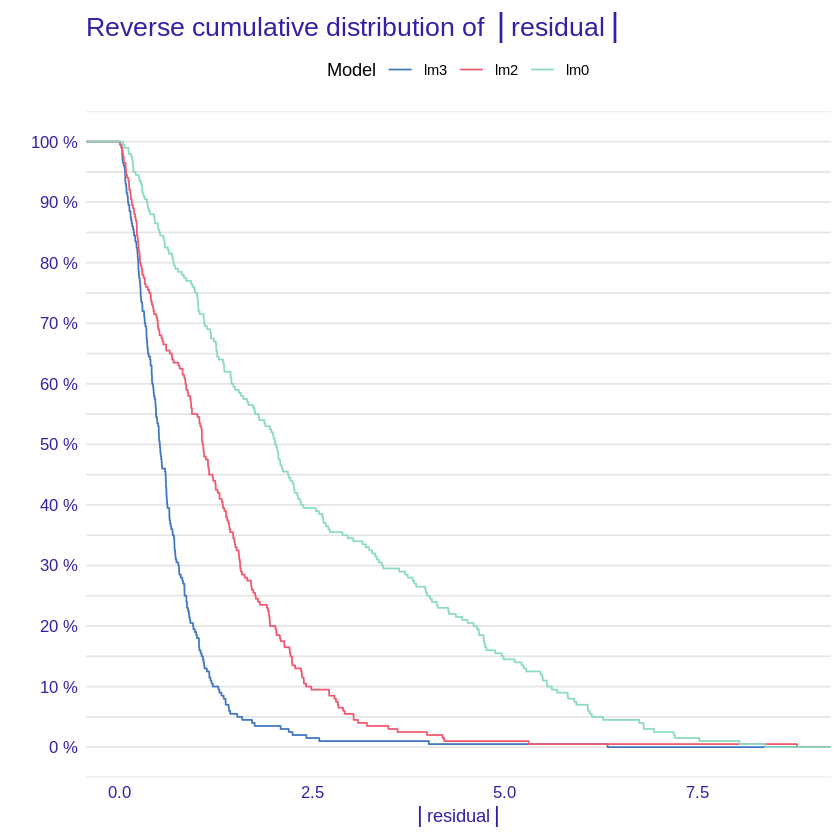

In [ ]:
plot(lm0,lm2, lm3)

Interprete el gráfico y escoja el mejor modelo, usando el criterio: curva menor o más
baja, es mejor. Explique a partir del gráfico, por qué este criterio tiene sentido para
justificar que un modelo es mejor que otro.

El mejor modelo en base a la interpretación del gráfico es el mod3 ya que tiene la curva más baja. Una curva que cae rápidamente significa que la mayoría de los residuos (error entre la predicción del modelo y la realidad) son pequeños, lo que es deseable.

5.
Finalmente, y como último criterio, realice el análisis de varianza. Para escoger el
mejor modelo solamente debe tomar en cuenta el valor de Residual Sum of
Squares(RSS), donde a menor valor, mejor es el modelo, es decir, los puntos están
más ajustados.

Considere la siguiente instrucción para realizar este análisis:

In [ ]:
anova(mod0,mod1, mod2, mod3)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,198,2102.5306,NA,NA,NA,NA
2,196,556.8253,2,1545.70532023,272.04067681,2.829487e-57
3,197,556.9140,-1,-0.08871717,0.03122805,8.599151e-01
4,196,174.4834,1,382.43059744,134.61385841,4.952994e-24


El mejor modelo tomando solo en cuenta el RSS es el mod3, ya que la variabilidad de los puntos es la menor (menor dispersión de los residuos). Esto indica que las predicciones de mod3 se ajustan más estrechamente a los datos reales.

Conclusión:

En base a todas las pruebas realizadas, el mod3 resultó el mejor.

#Caso 7 : Modelos de Regresión No Lineal (RNLS) – Mandíbulas de Venados
Este notebook realiza el análisis del Caso 7 – Longitud de mandíbula según edad en venados.

**Modelo 1**: Exponencial asintótico  
$$y = a(1 - e^{-c x})$$

**Modelo 2**: Logístico  
$$y = \frac{L}{1 + e^{-k(x - x_0)}}$$

In [ ]:
# Cargar librerías
library(ggplot2)
library(dplyr)
library(readr)
install.packages("AICcmodavg")
library(AICcmodavg)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘reformulas’, ‘TMB’, ‘RcppArmadillo’, ‘RcppEigen’, ‘unmarked’, ‘VGAM’


Warning message in install.packages("AICcmodavg"):
“installation of package ‘VGAM’ had non-zero exit status”
Warning message in install.packages("AICcmodavg"):
“installation of package ‘TMB’ had non-zero exit status”
Warning message in install.packages("AICcmodavg"):
“installation of package ‘unmarked’ had non-zero exit status”
Warning message in install.packages("AICcmodavg"):
“installation of package ‘AICcmodavg’ had non-zero exit status”


ERROR: Error in library(AICcmodavg): there is no package called ‘AICcmodavg’


In [ ]:
# Cargar datos desde URL
url <- "https://raw.githubusercontent.com/ContraInfinito/jaws/main/jaws.txt"
datos <- read_delim(url, delim = "\t", col_types = cols())

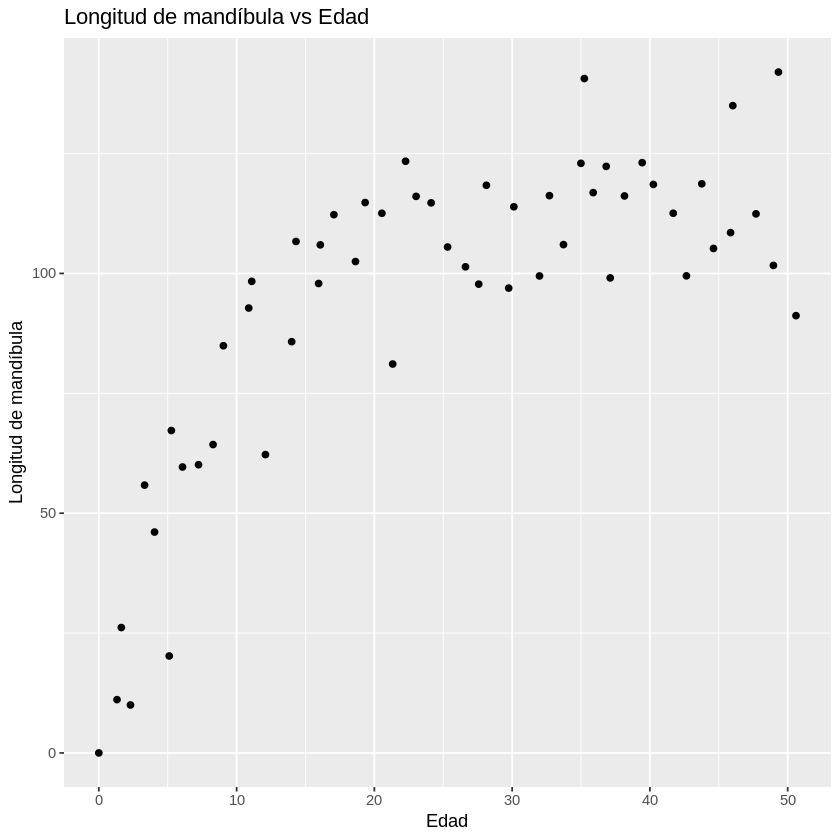

In [ ]:
# Gráfico de dispersión
ggplot(datos, aes(x = age, y = bone)) +
  geom_point() +
  labs(
    title = "Longitud de mandíbula vs Edad",
    x = "Edad",
    y = "Longitud de mandíbula"
  )

In [ ]:
# Modelo 1: y = a(1 - exp(-c x))
model1 <- nls(
  bone ~ a * (1 - exp(-c * age)),
  data = datos,
  start = list(a = 120, c = 0.064)
)
coef1 <- coef(model1)
a1 <- coef1["a"]
c1 <- coef1["c"]
cat(sprintf("Modelo 1: y = %.3f * (1 - exp(-%.4f * x))\n", a1, c1))


Modelo 1: y = 115.581 * (1 - exp(-0.1188 * x))


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


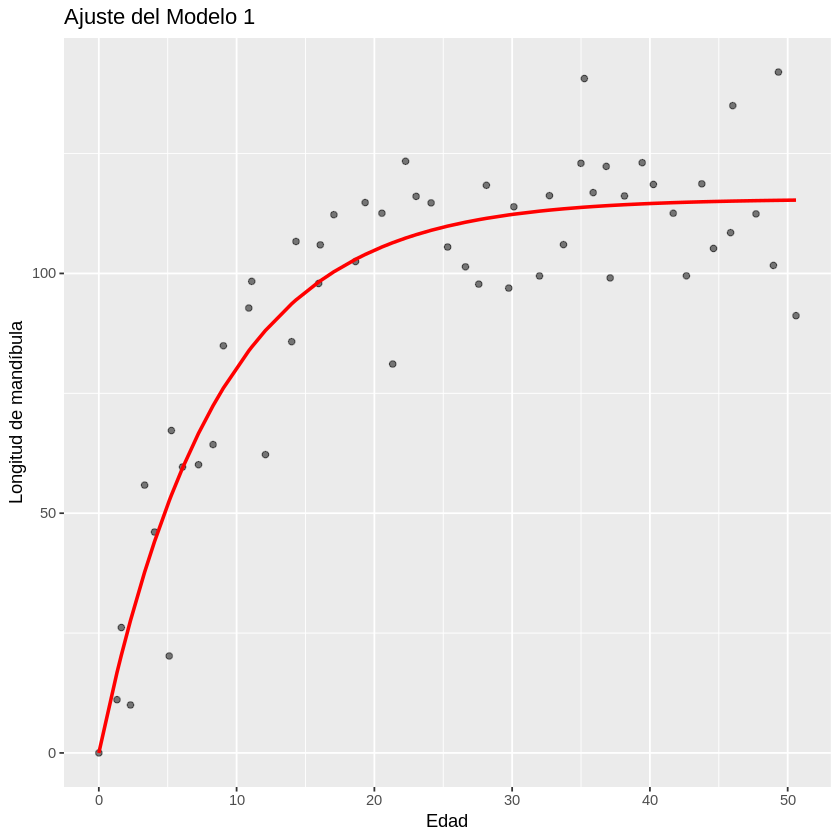

In [ ]:
# Gráfico del modelo 1
datos1 <- datos %>%
  mutate(pred1 = predict(model1, newdata = datos))
ggplot(datos1, aes(x = age)) +
  geom_point(aes(y = bone), alpha = 0.5) +
  geom_line(aes(y = pred1), color = "red", size = 1) +
  labs(
    title = "Ajuste del Modelo 1",
    x = "Edad",
    y = "Longitud de mandíbula"
  )

In [ ]:
# Linealización para modelo logístico
L <- 145  # Valor máximo observado

# Filtrar para transformación válida: bone < L y bone > 0
datos_filt <- datos %>%
  filter(bone < L, bone > 0) %>%
  mutate(
    y_trans = log((L / bone) - 1)
  )

lin_mod <- lm(y_trans ~ age, data = datos_filt)
slope   <- coef(lin_mod)["age"]
interc  <- coef(lin_mod)["(Intercept)"]
k_init  <- -slope
x0_init <- interc / slope
cat(sprintf("Estimaciones iniciales: k = %.4f, x0 = %.4f\n", k_init, x0_init))


Estimaciones iniciales: k = 0.0563, x0 = -11.6147


In [ ]:
# Modelo 2: Logístico
model2 <- nls(
  bone ~ L / (1 + exp(-k * (age - x0))),
  data = datos,
  start = list(L = L, k = k_init, x0 = x0_init)
)
coef2 <- coef(model2)
L2  <- coef2["L"]
k2  <- coef2["k"]
x02 <- coef2["x0"]
cat(sprintf("Modelo 2: y = %.2f / (1 + exp(-%.4f * (x - %.4f)))\n",
            L2, k2, x02))

Modelo 2: y = 112.41 / (1 + exp(-0.2678 * (x - 6.5830)))


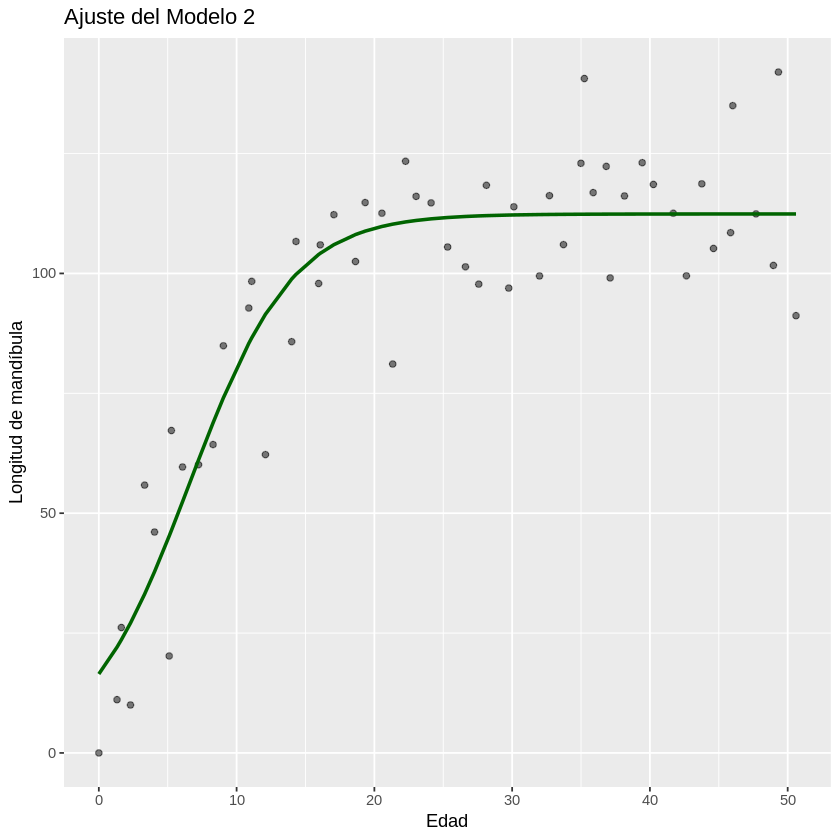

In [ ]:
# Gráfico del modelo 2
datos2 <- datos %>%
  mutate(pred2 = predict(model2, newdata = datos))
ggplot(datos2, aes(x = age)) +
  geom_point(aes(y = bone), alpha = 0.5) +
  geom_line(aes(y = pred2), color = "darkgreen", size = 1) +
  labs(
    title = "Ajuste del Modelo 2",
    x = "Edad",
    y = "Longitud de mandíbula"
  )

**Comparación de Modelos**

Se comparan los modelos utilizando el Error Cuadrático de los Residuos (RSS)

El modelo exponencial asintótico (Modelo 1) presenta un menor RSS, indicando mejor ajuste.


In [ ]:
# Comparación de modelos
# Calcular residuos y RSS
rss1 <- sum(resid(model1)^2)
rss2 <- sum(resid(model2)^2)
cat(sprintf("RSS Modelo 1: %.2f\nRSS Modelo 2: %.2f\n", rss1, rss2))

anova_res <- anova(model1, model2)
print(anova_res)
# Crea la tabla de AICc
tabla_aicc <- AICctab(
  list(model1, model2),
  modnames = c("Exponencial", "Logístico"),
  second.ord = TRUE   # para que use AICc en vez de AIC
)
print(tabla_aicc)

**Conclusión**

Ambos modelos se ajustan razonablemente bien a los datos observados. Sin embargo, el modelo exponencial asintótico (Modelo 1) presenta un menor error cuadrático residual (RSS), lo que indica un mejor ajuste global a los datos.
Aunque el modelo logístico puede reflejar mejor una saturación biológica teórica, desde el punto de vista del ajuste numérico, el Modelo 1 es preferible.

Gráficamente, se observa que el modelo exponencial sigue más de cerca las tendencias en los valores reales de mandíbula frente a la edad.
